## Univariate Exploratory data analysis (EDA) - Manual

### By:
Gabriel Múnera González

### Date:
2026-08-20

### Description:

Univariate Exploratory data analysis (EDA) and description of the data set.

Data manipulation and visualization


## 📚 Import  libraries

In [2]:
# base libraries for data science
import sys
from pathlib import Path

import pandas as pd

In [3]:
# configuration to show only 2 decimal places
pd.set_option("display.float_format", "{:.2f}".format)

In [4]:
# print library version for reproducibility

print("Python version: ", sys.version)
print("Pandas version: ", pd.__version__)

Python version:  3.12.11 (main, Jul  1 2025, 05:29:09) [GCC 12.2.0]
Pandas version:  2.3.3


## 💾 Load data

The dataset has correct data types, fixed in:

`notebooks/2-exploration/01-jrz-data_explore_description-2024_03_01.ipynb`

In [5]:
DATA_DIR = Path.cwd().resolve().parents[1] / "data"


diamantes_df = pd.read_parquet(
    DATA_DIR / "02_intermediate/diamantes_type_fixed.parquet", engine="pyarrow"
)

## 📊 Data description

### General data information

General information about the data set:

In [6]:
diamantes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54492 entries, 0 to 54491
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    54492 non-null  float32 
 1   cut      54492 non-null  category
 2   color    54492 non-null  category
 3   clarity  54492 non-null  category
 4   depth    54492 non-null  float32 
 5   table    54492 non-null  float32 
 6   price    54492 non-null  int64   
 7   x        54492 non-null  float32 
 8   y        54492 non-null  float32 
 9   z        54492 non-null  float32 
dtypes: category(3), float32(6), int64(1)
memory usage: 1.8 MB


In [7]:
# size of the dataframe
diamantes_df.shape

(54492, 10)

In [8]:
# sample of the dataframe
diamantes_df.sample(5)

,carat,cut,color,clarity,depth,table,price,x,y,z
46200,0.55,Very Good,E,VS2,61.40,57.00,1786,5.27,5.29,3.24
6096,0.90,Premium,F,SI1,62.30,58.00,4047,6.18,6.12,3.83
31619,0.30,Premium,F,VS2,62.80,58.00,776,4.28,4.25,2.68
38191,0.35,Ideal,F,IF,60.90,56.00,1035,4.54,4.56,2.77
53989,0.80,Premium,F,SI2,61.70,58.00,2762,5.98,5.94,3.68


Number of missing values

In [9]:
diamantes_df.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

Target Variable = `price`

#### General statistics of the data set

##### Numerical variables

In [10]:
diamantes_df.describe()

,carat,depth,table,price,x,y,z
count,54492.00,54492.00,54492.00,54492.00,54492.00,54492.00,54492.00
mean,0.80,61.75,57.46,3927.93,5.73,5.74,3.54
std,0.47,1.43,2.24,3970.89,1.12,1.14,0.70
min,0.20,43.00,43.00,326.00,0.00,0.00,0.00
25%,0.40,61.00,56.00,956.00,4.72,4.73,2.91
50%,0.70,61.80,57.00,2443.00,5.70,5.72,3.53
75%,1.04,62.50,59.00,5286.25,6.54,6.53,4.03
max,5.01,79.00,95.00,18823.00,10.74,58.90,31.80


##### Categorical variables

In [11]:
# categorical columns description
diamantes_df.describe(include="category")

,cut,color,clarity
count,54492,54492,54492
unique,5,7,8
top,Ideal,G,SI1
freq,21690,11388,13204


### 📈  Univariate Analysis

#### Target Variable
`price` is the target variable, which is a numerical variable. The distribution of the target variable is shown below.

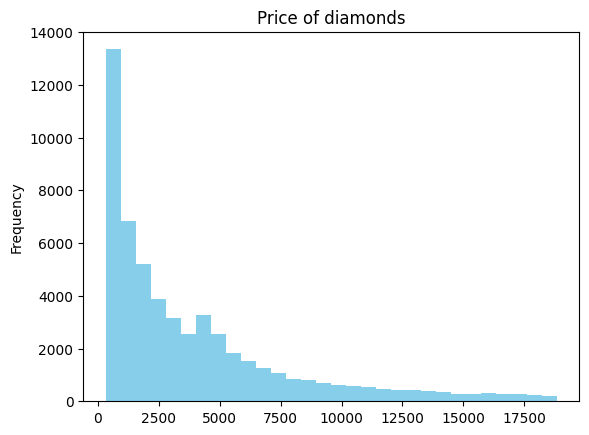

In [12]:
diamantes_df["price"].plot(
    kind="hist", color=["skyblue", "orange"], title="Price of diamonds", bins=30
);

#### Numerical Variables

In [14]:
# list of the numerical columns
numerical_columns = list(diamantes_df.select_dtypes(include=["number"]).columns)
numerical_columns

['carat', 'depth', 'table', 'price', 'x', 'y', 'z']

##### carat

In [16]:
column = "carat"
diamantes_df[column].describe()

count   54492.00
mean        0.80
std         0.47
min         0.20
25%         0.40
50%         0.70
75%         1.04
max         5.01
Name: carat, dtype: float64

In [17]:
# number of unique values
diamantes_df[column].nunique()

273

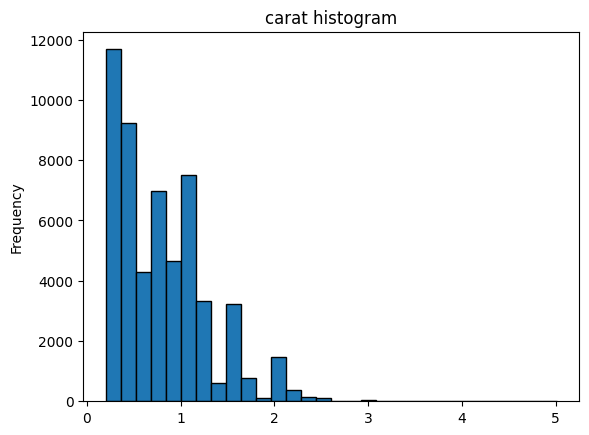

In [ ]:
diamantes_df[column].plot(kind="hist", bins=30, edgecolor="black", title=f"{column} histogram");

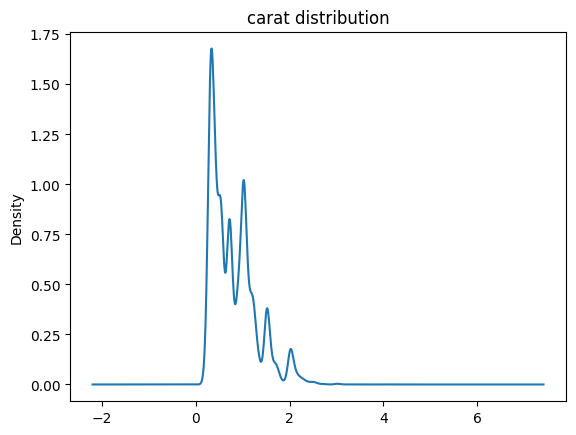

In [20]:
diamantes_df[column].plot(kind="density", title=f"{column} distribution");

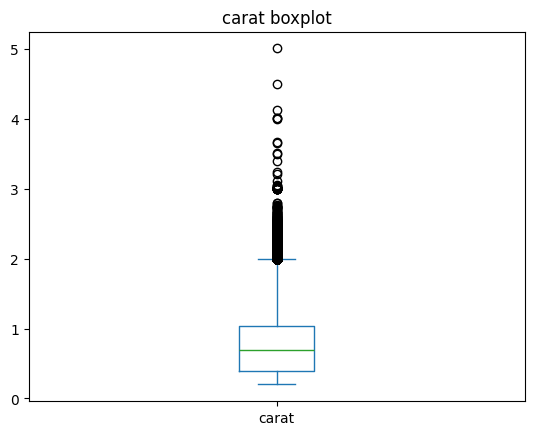

In [21]:
diamantes_df[column].plot(kind="box", title=f"{column} boxplot");

##### depth

In [23]:
column = "depth"
diamantes_df[column].describe()

count   54492.00
mean       61.75
std         1.43
min        43.00
25%        61.00
50%        61.80
75%        62.50
max        79.00
Name: depth, dtype: float64

In [24]:
# number of unique values
diamantes_df[column].nunique()

184

In [25]:
# unique values (because are only a few)
diamantes_df[column].unique()

array([61.5, 59.8, 56.9, 62.4, 63.3, 62.8, 62.3, 61.9, 65.1, 59.4, 64. ,
       60.4, 62.2, 60.2, 60.9, 62. , 63.4, 63.8, 62.7, 61. , 58.1, 62.5,
       60.5, 60. , 60.7, 59.5, 58.2, 64.1, 60.8, 61.8, 61.2, 61.6, 59.3,
       62.6, 63. , 63.2, 63.1, 62.9, 63.7, 59.2, 59.9, 62.1, 57.5, 66.3,
       58.8, 61.4, 59.6, 64.4, 65.7, 63.6, 61.3, 60.1, 60.3, 61.7, 60.6,
       55.1, 61.1, 65.8, 58. , 63.5, 66.4, 64.6, 64.3, 58.5, 59.7, 57.2,
       64.9, 59.1, 59. , 58.9, 66.7, 58.7, 57.7, 65.4, 64.2, 58.4, 53.3,
       53. , 67.8, 67.9, 66.1, 64.5, 55.8, 67.6, 68.2, 58.3, 65.5, 65.3,
       67.7, 69.5, 63.9, 56.6, 65. , 56.3, 66.9, 57.9, 65.2, 66. , 67. ,
       57.6, 56. , 67.1, 58.6, 65.6, 64.8, 69.3, 66.2, 55.4, 66.8, 68.1,
       64.7, 66.6, 55.9, 57.3, 57.4, 68.3, 68.5, 56.2, 65.9, 56.5, 56.1,
       57.8, 66.5, 68.4, 69.7, 57.1, 68.7, 56.7, 68.6, 71.6, 67.3, 43. ,
       68.8, 67.4, 67.5, 69. , 55.2, 68.9, 69.6, 57. , 56.4, 56.8, 44. ,
       67.2, 70.1, 71.3, 70.6, 69.8, 71.8, 53.8, 53

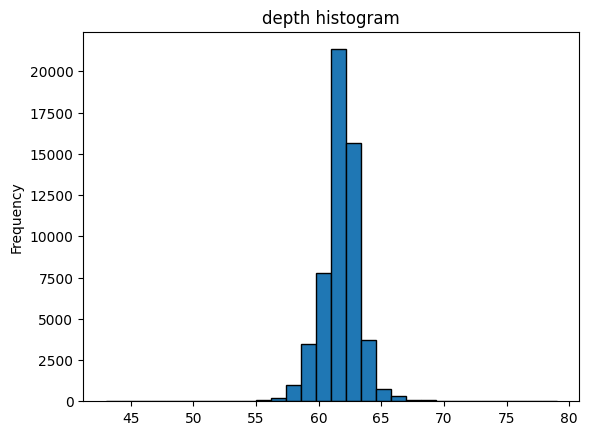

In [ ]:
# histogram of a column with 7 unique values between 0 and 8
diamantes_df[column].plot(kind="hist", bins=30, edgecolor="black", title=f"{column} histogram");

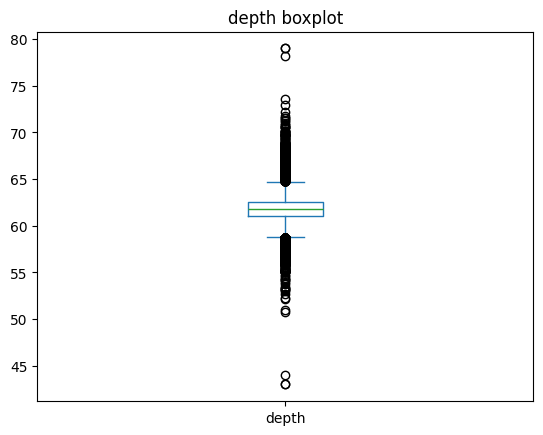

In [28]:
diamantes_df[column].plot(kind="box", title=f"{column} boxplot");

##### table

In [29]:
column = "table"
diamantes_df[column].describe()

count   54492.00
mean       57.46
std         2.24
min        43.00
25%        56.00
50%        57.00
75%        59.00
max        95.00
Name: table, dtype: float64

In [30]:
# number of unique values
diamantes_df[column].nunique()

127

In [31]:
# unique values (because are only a few)
diamantes_df[column].unique()

array([55. , 61. , 65. , 58. , 57. , 56. , 54. , 62. , 59. , 60. , 53. ,
       64. , 63. , 67. , 55.8, 54.4, 57.1, 53.6, 54.8, 54.2, 70. , 54.9,
       56.7, 69. , 52. , 53.9, 66. , 57.8, 54.1, 55.1, 51. , 58.1, 56.9,
       56.5, 53.7, 60.7, 56.2, 56.6, 56.1, 56.3, 57.2, 68. , 57.5, 60.9,
       56.4, 59.8, 62.3, 60.1, 55.9, 50.1, 62.2, 54.5, 55.7, 53.4, 54.7,
       58.8, 59.4, 62.5, 54.3, 60.6, 55.2, 58.6, 49. , 55.3, 50. , 54.6,
       62.6, 57.7, 56.8, 57.9, 60.3, 55.6, 59.5, 57.4, 62.4, 60.4, 53.3,
       60.2, 60.8, 58.5, 57.6, 43. , 59.9, 63.5, 57.3, 61.4, 58.3, 55.4,
       58.2, 53.5, 59.7, 55.5, 58.7, 53.8, 59.1, 53.2, 59.3, 61.1, 51.6,
       95. , 61.2, 59.2, 60.5, 58.4, 53.1, 52.8, 44. , 61.3, 61.9, 61.8,
       59.6, 61.5, 58.9, 64.3, 62.8, 71. , 52.4, 63.3, 61.7, 64.2, 73. ,
       65.4, 63.4, 62.1, 79. , 76. , 61.6], dtype=float32)

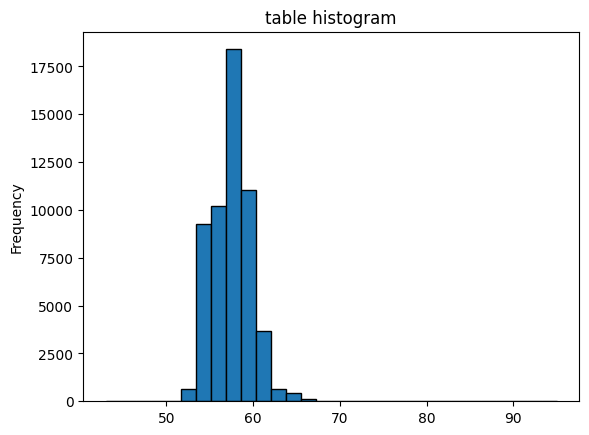

In [ ]:
diamantes_df[column].plot(kind="hist", bins=30, edgecolor="black", title=f"{column} histogram");

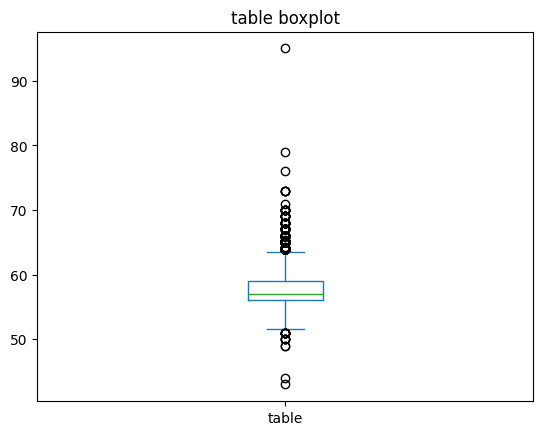

In [34]:
diamantes_df[column].plot(kind="box", title=f"{column} boxplot");

##### x

In [37]:
column = "x"
diamantes_df[column].describe()

count   54492.00
mean        5.73
std         1.12
min         0.00
25%         4.72
50%         5.70
75%         6.54
max        10.74
Name: x, dtype: float64

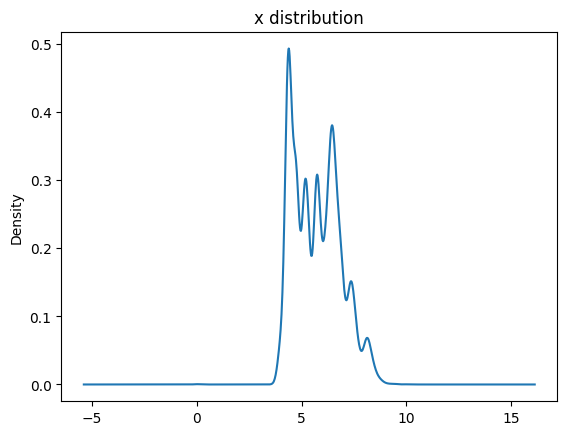

In [38]:
diamantes_df[column].plot(kind="kde", title=f"{column} distribution");

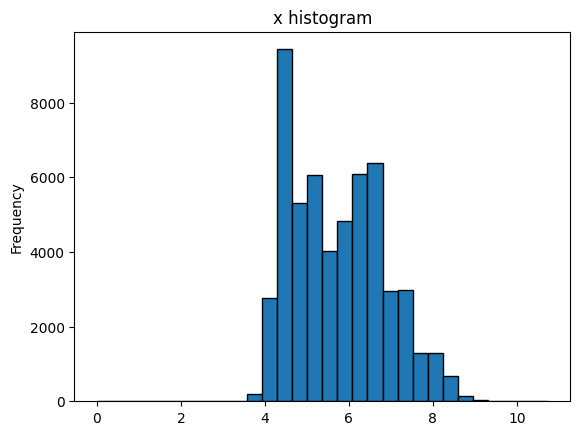

In [ ]:
diamantes_df[column].plot(kind="hist", bins=30, edgecolor="black", title=f"{column} histogram");

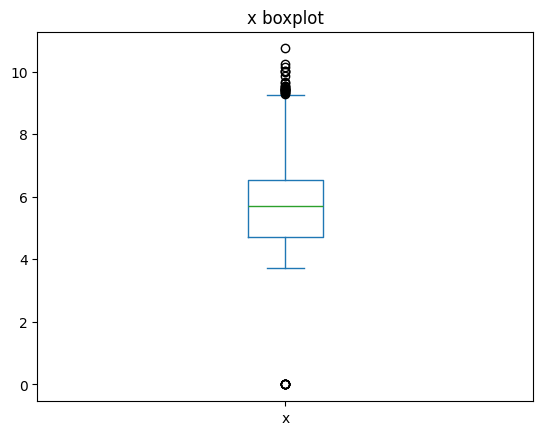

In [41]:
diamantes_df[column].plot(kind="box", title=f"{column} boxplot");

##### y

In [43]:
column = "y"
diamantes_df[column].describe()

count   54492.00
mean        5.74
std         1.14
min         0.00
25%         4.73
50%         5.72
75%         6.53
max        58.90
Name: y, dtype: float64

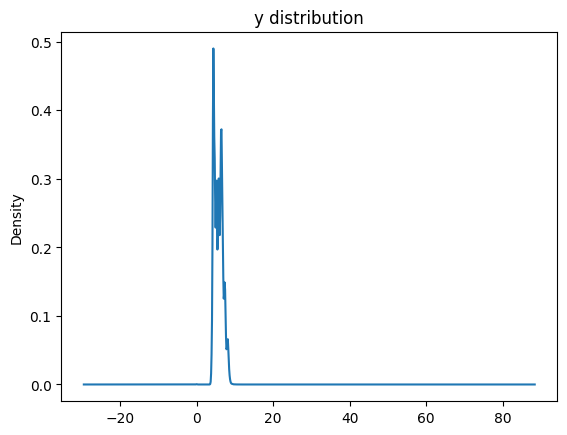

In [44]:
diamantes_df[column].plot(kind="kde", title=f"{column} distribution");

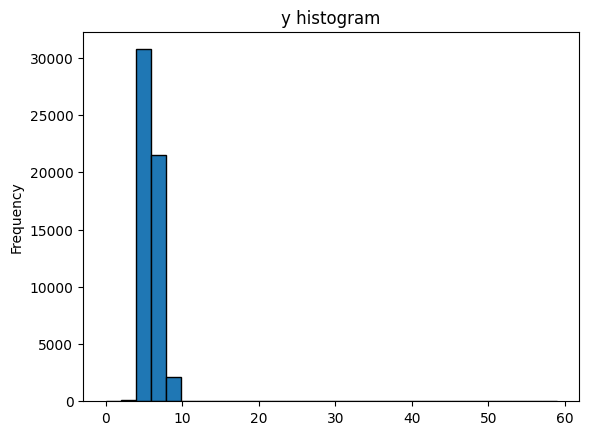

In [ ]:
diamantes_df[column].plot(kind="hist", bins=30, edgecolor="black", title=f"{column} histogram");

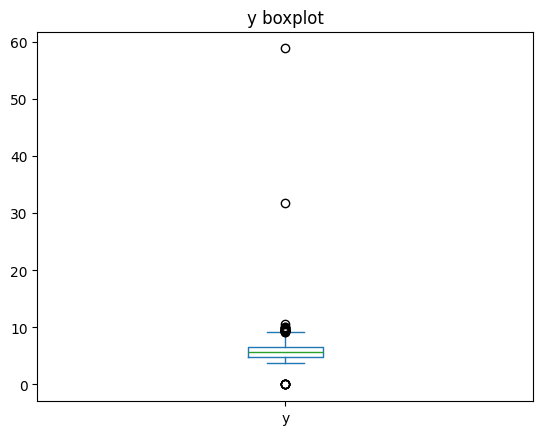

In [46]:
diamantes_df[column].plot(kind="box", title=f"{column} boxplot");

##### z

In [47]:
column = "z"
diamantes_df[column].describe()

count   54492.00
mean        3.54
std         0.70
min         0.00
25%         2.91
50%         3.53
75%         4.03
max        31.80
Name: z, dtype: float64

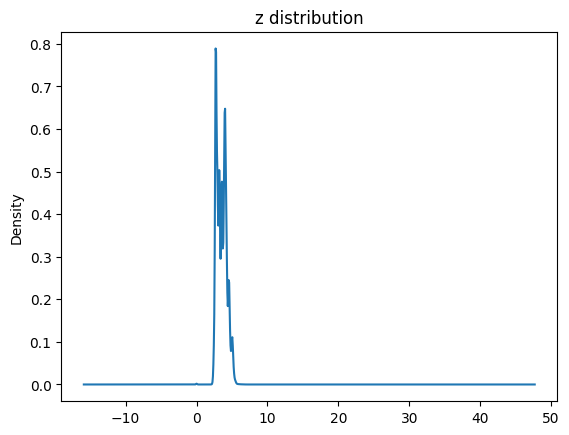

In [48]:
diamantes_df[column].plot(kind="kde", title=f"{column} distribution");

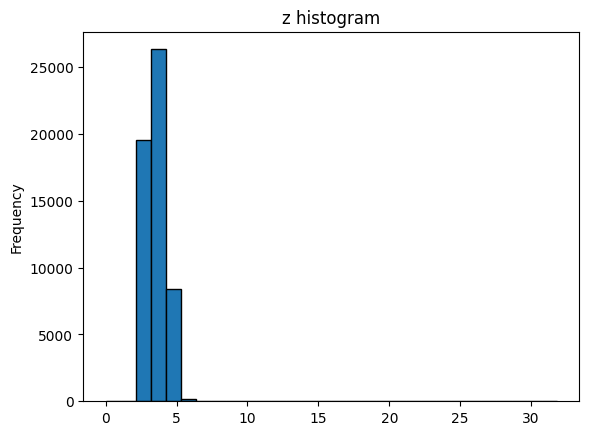

In [ ]:
diamantes_df[column].plot(kind="hist", bins=30, edgecolor="black", title=f"{column} histogram");

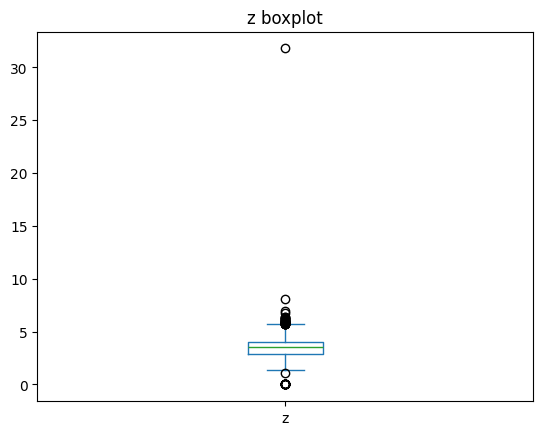

In [50]:
diamantes_df[column].plot(kind="box", title=f"{column} boxplot");

##### price

In [51]:
column = "price"
diamantes_df[column].describe()

count   54492.00
mean     3927.93
std      3970.89
min       326.00
25%       956.00
50%      2443.00
75%      5286.25
max     18823.00
Name: price, dtype: float64

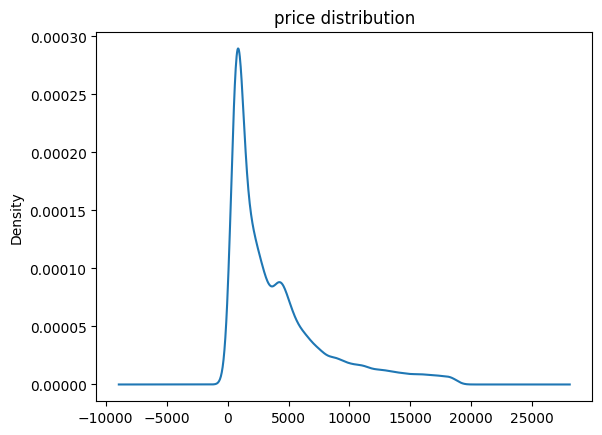

In [52]:
diamantes_df[column].plot(kind="kde", title=f"{column} distribution");

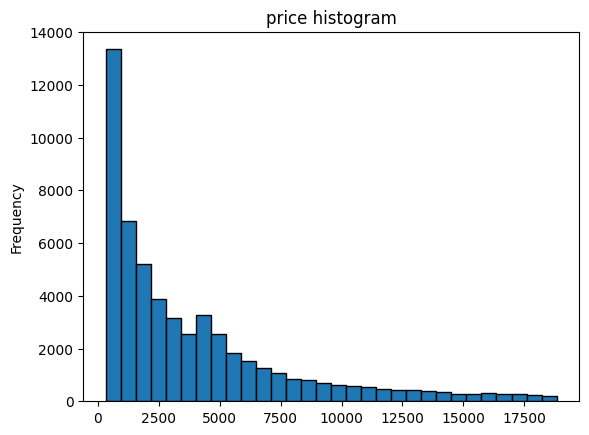

In [ ]:
diamantes_df[column].plot(kind="hist", bins=30, edgecolor="black", title=f"{column} histogram");

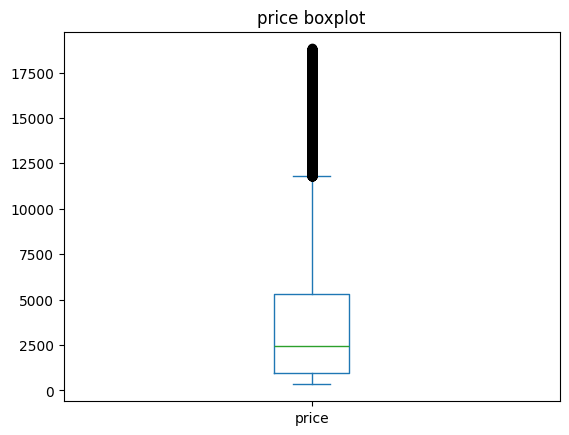

In [54]:
diamantes_df[column].plot(kind="box", title=f"{column} boxplot");

#### Categorical Variables

In [42]:
# list of the categorical columns
categorical_columns = list(diamantes_df.select_dtypes(include=["category"]).columns)
categorical_columns

['cut', 'color', 'clarity']

##### cut

In [57]:
column = "cut"
diamantes_df[column].describe()

count     54492
unique        5
top       Ideal
freq      21690
Name: cut, dtype: object

In [58]:
diamantes_df[column].unique()

['Ideal', 'Premium', 'Good', 'Very Good', 'Fair']
Categories (5, object): ['Fair', 'Good', 'Ideal', 'Premium', 'Very Good']

In [59]:
diamantes_df[column].value_counts()

cut
Ideal        21690
Premium      13954
Very Good    12238
Good          4973
Fair          1637
Name: count, dtype: int64

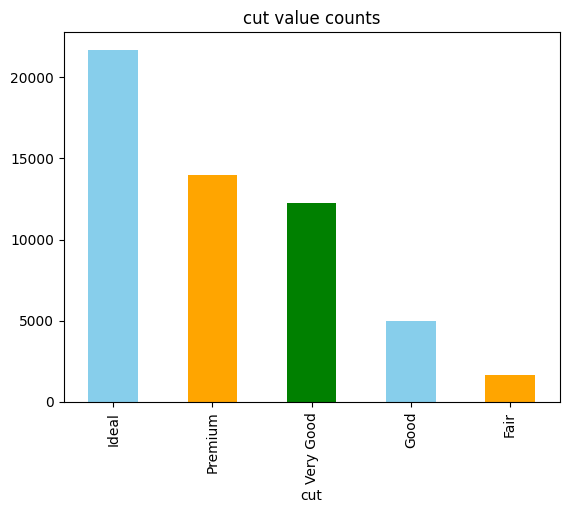

In [60]:
diamantes_df[column].value_counts().plot(
    kind="bar", color=["skyblue", "orange", "green"], title=f"{column} value counts"
);

##### color

In [62]:
column = "color"
diamantes_df[column].describe()

count     54492
unique        7
top           G
freq      11388
Name: color, dtype: object

In [63]:
diamantes_df[column].unique()

['E', 'I', 'J', 'H', 'F', 'G', 'D']
Categories (7, object): ['D', 'E', 'F', 'G', 'H', 'I', 'J']

In [64]:
diamantes_df[column].value_counts()

color
G    11388
E     9920
F     9646
H     8407
D     6823
I     5462
J     2846
Name: count, dtype: int64

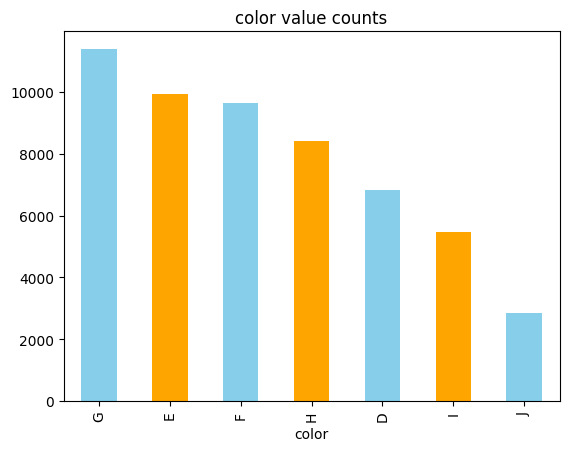

In [65]:
diamantes_df[column].value_counts().plot(
    kind="bar", color=["skyblue", "orange"], title=f"{column} value counts"
);

##### clarity

In [66]:
column = "clarity"
diamantes_df[column].describe()

count     54492
unique        8
top         SI1
freq      13204
Name: clarity, dtype: object

In [67]:
diamantes_df[column].unique()

['SI2', 'SI1', 'VS1', 'VS2', 'VVS2', 'VVS1', 'I1', 'IF']
Categories (8, object): ['I1', 'IF', 'SI1', 'SI2', 'VS1', 'VS2', 'VVS1', 'VVS2']

In [68]:
diamantes_df[column].value_counts()

clarity
SI1     13204
VS2     12348
SI2      9360
VS1      8264
VVS2     5093
VVS1     3672
IF       1801
I1        750
Name: count, dtype: int64

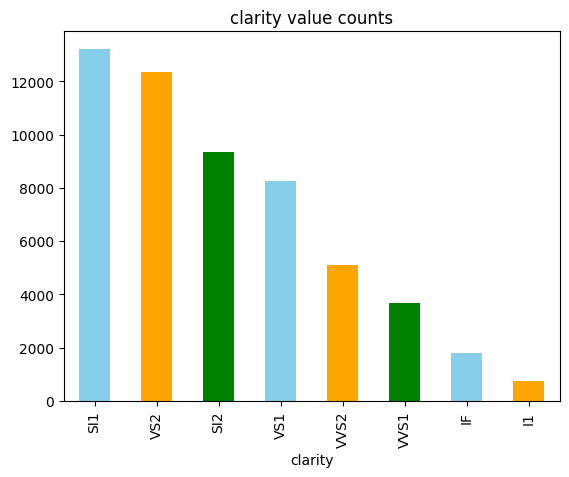

In [69]:
diamantes_df[column].value_counts().plot(
    kind="bar", color=["skyblue", "orange", "green"], title=f"{column} value counts"
);

#### String columns

No string columns in the data set.

## 📊 Analysis of Results and Conclusions

#### Data quality

- No missing values in any of the 10 columns (54,492 rows, fully dense).
- `x`, `y`, `z` (physical dimensions, mm) each have a **minimum of 0**, which is physically
  impossible for a diamond and indicates data-entry errors, not real measurements.
- `y` and `z` also contain extreme outliers unrelated to the rest of the distribution
  (`y` max 58.90mm vs. a 75th percentile of 6.53mm; `z` max 31.80mm vs. a 75th percentile
  of 4.03mm) — visible as isolated points far above the whiskers in their boxplots.
  Both the zero values and these extreme values should be treated as errors and
  cleaned (dropped or imputed) before modeling.

#### Target variable (`price`)

- Strongly right-skewed: median \$2,443 vs. mean \$3,928 (mean pulled up by the tail),
  ranging from \$326 to \$18,823.
- Most diamonds are inexpensive — the histogram shows a sharp peak below \$2,500 with a
  long tail of progressively rarer, more expensive stones, plus a small secondary bump
  around \$4,000–4,500.
- The skew suggests a log-transform of `price` is worth trying for linear-style models.

#### Numerical variables

- `carat`, `x`, `y`, `z` all show the same right-skewed shape (small/light diamonds are
  far more common than large ones), which is expected since these are all measures of
  the same physical size and should correlate strongly with each other and with `price`.
- `depth` and `table` are the best-behaved numerical features: roughly symmetric,
  tightly clustered (`depth` mostly 55–70%, `table` mostly 53–64%), though both have a
  number of mild outliers on both tails worth a sanity check (e.g. `table` max of 95%
  and `depth` min of 43%/max of 79% look implausible for a well-cut diamond).

#### Categorical variables

- `cut`: dominated by **Ideal** (~40%) and **Premium** (~26%); **Fair** is rare (~3%) —
  moderate imbalance across the 5 grades.
- `color`: relatively balanced across the 7 grades (D–J), with **G** most common (~21%)
  and **J** least common (~5%).
- `clarity`: **SI1** and **VS2** together make up almost half the data (~47%), while the
  best (**IF**) and worst (**I1**) grades are both rare (~3% and ~1.4%) — the 8 grades
  are imbalanced at the extremes.

#### Next steps

- Clean the invalid/outlier `x`, `y`, `z` values before any modeling or bivariate work.
- Evaluate a log-transform for `price` (and possibly `carat`) given the skew.
- Treat `cut`, `color`, `clarity` as ordinal (they already have a natural quality order)
  rather than plain nominal categories when encoding for modeling.
- Move to bivariate analysis to check how strongly `carat`/`x`/`y`/`z` correlate with
  each other and with `price`, since a lot of that redundancy is already visible here.

## 📖 References

Visualización

- <https://joserzapata.github.io/courses/python-ciencia-datos/visualizacion/#visualizacion-con-pandas>
- <https://joserzapata.github.io/courses/python-ciencia-datos/visualizacion/plotly/>
- <https://joserzapata.github.io/courses/python-ciencia-datos/visualizacion/seaborn/>

EDA
- <https://www.analyticsvidhya.com/blog/2022/02/a-quick-guide-to-bivariate-analysis-in-python/>
- <https://www.kaggle.com/code/allohvk/titanic-advanced-eda>
- <https://www.kaggle.com/code/imkushwaha/bivariate-multivariate-analysis>

Statistical tests

- <https://nathanrosidi.medium.com/commonly-used-statistical-tests-in-data-science-93787568eb36>